In [1]:
# ============================================
# 🌱 PlantWhisper - Notebook 03
# Parametric Acoustic Synthesis
# ============================================
#
# This notebook generates plant "voice" audio based on:
# 1. Stress level from vision pipeline
# 2. Tel Aviv paper's empirical findings
# 3. Real ultrasonic pop spectral profiles
#
# Scientific basis: Khait et al. 2023 (Cell)
# "Sounds emitted by plants under stress are airborne and informative"
# ============================================

# ============================================
# 1. Setup & Imports
# ============================================

!pip install -q scipy numpy matplotlib librosa soundfile

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal
from scipy.ndimage import gaussian_filter1d
import librosa
import librosa.display
import soundfile as sf
from pathlib import Path
import json
import os
from IPython.display import Audio, display
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

# Paths
BASE_DIR = Path('/content/drive/MyDrive/PlantWhisper')
DATA_DIR = BASE_DIR / 'data' / 'telaviv'
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

print("✓ Setup complete")

# ============================================
# 2. Load Stress Profile from Notebook 02
# ============================================
# ============================================
# 2. Load Stress Profile from Notebook 02
# ============================================

# Load the IMPROVED profiles (v2)
profile_path = OUTPUT_DIR / 'stress_profiles_v2.json'

with open(profile_path) as f:
    stress_profiles = json.load(f)

print(f"✓ Loaded {len(stress_profiles)} stress profiles")

# Show summary
print(f"\n{'Image':<40} {'Stress Type':<25} {'Stress':<8} {'Pops/hr':<10}")
print("-" * 85)
for p in stress_profiles:
    img_name = Path(p.get('image_path', 'unknown')).name[:38]
    stress_type = p['stress_type'][:23]
    print(f"{img_name:<40} {stress_type:<25} {p['stress_level']:<8.2f} {p['pop_rate']:<10.1f}")

Mounted at /content/drive
✓ Setup complete
✓ Loaded 6 stress profiles

Image                                    Stress Type               Stress   Pops/hr   
-------------------------------------------------------------------------------------
istockphoto-1276445035-612x612.jpg       Tomato with Late Blight   0.75     26.6      
istockphoto-599962684-612x612.jpg        Grape with Esca (Black    0.68     30.4      
images (1).jfif                          Tomato with Late Blight   0.69     30.0      
images.jfif                              Grape with Esca (Black    0.78     24.6      
istockphoto-496662675-612x612.jpg        Healthy Raspberry Plant   0.06     2.8       
360_F_1244777686_APGlUk2ralLjKTnihzkBP   Tomato with Early Bligh   0.56     34.5      


In [2]:
# ============================================
# 3. Tel Aviv Paper Parameters
# ============================================
# From Khait et al. 2023 (Cell)
# https://doi.org/10.1016/j.cell.2023.03.009

TEL_AVIV_PARAMS = {
    # Recording parameters
    'original_sample_rate': 500_000,  # 500 kHz ultrasonic
    'clip_duration_ms': 2,            # 2ms per pop
    'samples_per_clip': 1000,         # 500kHz × 2ms

    # Frequency characteristics
    'peak_freq_hz': 53_000,           # ~49-58 kHz range, center ~53kHz
    'freq_std_hz': 5_000,             # Variation in peak frequency
    'bandwidth_hz': 20_000,           # Broadband click ~20kHz wide

    # Emission rates (from Figure 2)
    'healthy_pops_per_hour': 1,       # Control plants
    'drought_peak_pops_per_hour': 35, # Day 4-5 of drought
    'cut_peak_pops_per_hour': 25,     # Cut stems

    # Temporal pattern
    'pop_duration_ms': 1.5,           # Individual pop ~1-2ms
    'inter_pop_interval_min_ms': 50,  # Minimum gap between pops
}

print("✓ Tel Aviv parameters loaded")
print(f"  Original sample rate: {TEL_AVIV_PARAMS['original_sample_rate']/1000:.0f} kHz")
print(f"  Peak frequency: {TEL_AVIV_PARAMS['peak_freq_hz']/1000:.0f} kHz")
print(f"  Drought emission rate: {TEL_AVIV_PARAMS['drought_peak_pops_per_hour']} pops/hour")


✓ Tel Aviv parameters loaded
  Original sample rate: 500 kHz
  Peak frequency: 53 kHz
  Drought emission rate: 35 pops/hour


In [3]:

# ============================================
# 4. Load Real Tel Aviv Audio (if available)
# ============================================

def find_telaviv_files(data_dir):
    """Find all wav files from Tel Aviv dataset"""
    data_dir = Path(data_dir)

    if not data_dir.exists():
        print(f"⚠ Tel Aviv data not found at {data_dir}")
        return {}

    categories = {}
    for subdir in data_dir.iterdir():
        if subdir.is_dir():
            wav_files = list(subdir.glob('*.wav'))
            if wav_files:
                categories[subdir.name] = wav_files
                print(f"  {subdir.name}: {len(wav_files)} files")

    return categories

print("\nSearching for Tel Aviv audio files...")
telaviv_files = find_telaviv_files(DATA_DIR)

if telaviv_files:
    print(f"\n✓ Found {sum(len(f) for f in telaviv_files.values())} total files")
else:
    print("\n⚠ No Tel Aviv files found - will use synthetic generation")


Searching for Tel Aviv audio files...
  Tobacco Cut: 506 files
  Tobacco Dry: 275 files
  Tomato Cut: 660 files
  Tomato Dry: 1622 files
  Empty Pot: 1036 files
  Greenhouse Noises: 1378 files

✓ Found 5477 total files


In [4]:
# ============================================
# 5. Analyze Real Pop Spectral Profile
# ============================================

def analyze_pop_profile(wav_path, params=TEL_AVIV_PARAMS):
    """
    Analyze a real plant pop recording to extract spectral profile.
    Returns the average spectral envelope we can use for synthesis.
    """
    # Load audio
    sr_original, audio = wavfile.read(wav_path)

    # Normalize
    if audio.dtype == np.int16:
        audio = audio.astype(np.float32) / 32768.0
    elif audio.dtype == np.int32:
        audio = audio.astype(np.float32) / 2147483648.0

    # Compute spectrogram
    n_fft = 256  # Small for 2ms clips
    hop_length = 64

    S = np.abs(librosa.stft(audio, n_fft=n_fft, hop_length=hop_length))

    # Average spectral profile
    spectral_profile = S.mean(axis=1)

    # Frequency axis
    freqs = librosa.fft_frequencies(sr=sr_original, n_fft=n_fft)

    # Find peak frequency
    peak_idx = np.argmax(spectral_profile)
    peak_freq = freqs[peak_idx]

    return {
        'spectral_profile': spectral_profile,
        'frequencies': freqs,
        'peak_frequency': peak_freq,
        'sample_rate': sr_original,
        'duration_samples': len(audio)
    }

# Find stressed plant recordings (check both naming conventions)
stressed_folders = ['Tomato Dry', 'Dry Tomato', 'Tobacco Dry', 'Dry Tobacco']
target_folder = None

for folder_name in stressed_folders:
    if folder_name in telaviv_files:
        target_folder = folder_name
        break

if target_folder:
    print(f"\nAnalyzing real plant pop recordings from '{target_folder}'...")

    # Sample files
    sample_files = telaviv_files[target_folder][:10]  # Analyze 10 files
    profiles = []

    for wav_file in sample_files:
        try:
            profile = analyze_pop_profile(wav_file)
            profiles.append(profile)
            print(f"  {wav_file.name}: peak @ {profile['peak_frequency']/1000:.1f} kHz, SR={profile['sample_rate']/1000:.0f}kHz")
        except Exception as e:
            print(f"  ✗ {wav_file.name}: {e}")

    if profiles:
        # Average spectral profile across samples
        avg_profile = np.mean([p['spectral_profile'] for p in profiles], axis=0)
        avg_freqs = profiles[0]['frequencies']
        real_sr = profiles[0]['sample_rate']
        avg_peak = np.mean([p['peak_frequency'] for p in profiles])

        print(f"\n✓ Extracted spectral profile from {len(profiles)} recordings")
        print(f"  Average peak frequency: {avg_peak/1000:.1f} kHz")
        print(f"  Sample rate: {real_sr/1000:.0f} kHz")

        REAL_SPECTRAL_PROFILE = {
            'profile': avg_profile,
            'frequencies': avg_freqs,
            'sample_rate': real_sr,
            'avg_peak_frequency': avg_peak
        }
    else:
        REAL_SPECTRAL_PROFILE = None
else:
    REAL_SPECTRAL_PROFILE = None
    print(f"\n⚠ No stressed plant folders found. Available: {list(telaviv_files.keys())}")


Analyzing real plant pop recordings from 'Tomato Dry'...
  id_35_sound_11.wav: peak @ 58.6 kHz, SR=500kHz
  id_35_sound_110.wav: peak @ 43.0 kHz, SR=500kHz
  id_35_sound_111.wav: peak @ 58.6 kHz, SR=500kHz
  id_35_sound_112.wav: peak @ 62.5 kHz, SR=500kHz
  id_35_sound_113.wav: peak @ 46.9 kHz, SR=500kHz
  id_35_sound_114.wav: peak @ 52.7 kHz, SR=500kHz
  id_35_sound_115.wav: peak @ 58.6 kHz, SR=500kHz
  id_35_sound_116.wav: peak @ 46.9 kHz, SR=500kHz
  id_35_sound_117.wav: peak @ 44.9 kHz, SR=500kHz
  id_35_sound_118.wav: peak @ 44.9 kHz, SR=500kHz

✓ Extracted spectral profile from 10 recordings
  Average peak frequency: 51.8 kHz
  Sample rate: 500 kHz


✓ Generated test pop: 88 samples


/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=256 is too large for input signal of length=88
  warnings.warn(


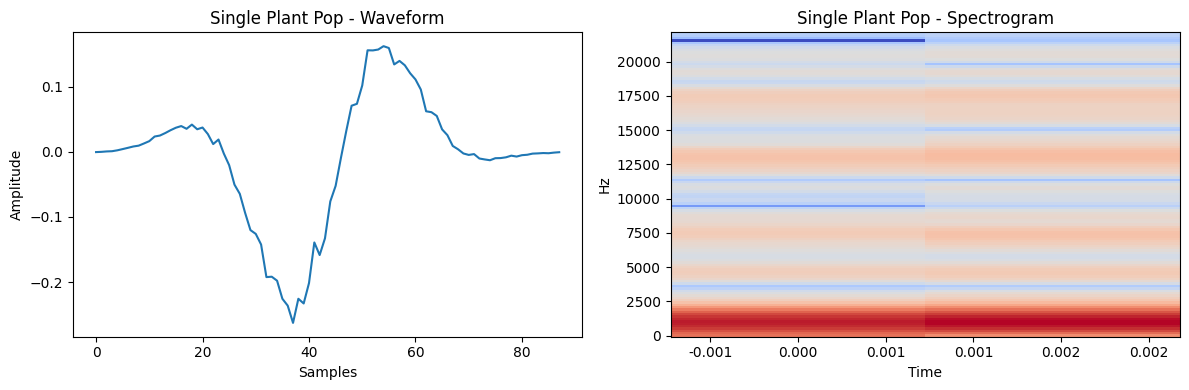


🔊 Playing single pop (you may need to turn up volume):


In [6]:

# ============================================
# 6. Synthetic Pop Generator
# ============================================

def generate_single_pop(
    duration_ms=2.0,
    sample_rate=44100,
    peak_freq_hz=1000,  # Already pitch-shifted for audible output
    bandwidth_hz=500,
    amplitude=0.8
):
    """
    Generate a single synthetic plant pop.

    This models the cavitation event in xylem vessels:
    - Broadband click with gaussian envelope
    - Peak around specified frequency
    - Duration ~1-2ms

    Args:
        duration_ms: Pop duration in milliseconds
        sample_rate: Output sample rate (Hz)
        peak_freq_hz: Center frequency (Hz) - use audible range
        bandwidth_hz: Frequency spread (Hz)
        amplitude: Peak amplitude (0-1)

    Returns:
        numpy array of audio samples
    """
    # Time array
    n_samples = int(sample_rate * duration_ms / 1000)
    t = np.linspace(0, duration_ms / 1000, n_samples)

    # Gaussian envelope (quick attack, quick decay)
    center = duration_ms / 2000  # Peak at center
    sigma = duration_ms / 6000   # Width
    envelope = np.exp(-((t - center) ** 2) / (2 * sigma ** 2))

    # Frequency content: sum of sinusoids with gaussian frequency distribution
    freqs = np.linspace(peak_freq_hz - bandwidth_hz, peak_freq_hz + bandwidth_hz, 20)
    freq_weights = np.exp(-((freqs - peak_freq_hz) ** 2) / (2 * (bandwidth_hz/2) ** 2))
    freq_weights /= freq_weights.sum()

    # Generate signal
    signal_out = np.zeros(n_samples)
    for f, w in zip(freqs, freq_weights):
        phase = np.random.uniform(0, 2 * np.pi)  # Random phase for natural sound
        signal_out += w * np.sin(2 * np.pi * f * t + phase)

    # Apply envelope and amplitude
    signal_out = signal_out * envelope * amplitude

    # Add slight noise for realism
    noise = np.random.randn(n_samples) * 0.02 * amplitude
    noise = noise * envelope  # Shape noise with same envelope
    signal_out += noise

    return signal_out

# Test single pop
test_pop = generate_single_pop(duration_ms=2.0, peak_freq_hz=1000, bandwidth_hz=400)
print(f"✓ Generated test pop: {len(test_pop)} samples")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Waveform
axes[0].plot(test_pop)
axes[0].set_title('Single Plant Pop - Waveform')
axes[0].set_xlabel('Samples')
axes[0].set_ylabel('Amplitude')

# Spectrogram
D = librosa.stft(test_pop, n_fft=256, hop_length=64)
librosa.display.specshow(librosa.amplitude_to_db(np.abs(D)), sr=44100,
                         hop_length=64, x_axis='time', y_axis='hz', ax=axes[1])
axes[1].set_title('Single Plant Pop - Spectrogram')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'single_pop_visualization.png', dpi=150)
plt.show()

# Play it
print("\n🔊 Playing single pop (you may need to turn up volume):")
display(Audio(test_pop, rate=44100))


In [9]:
# ============================================
# 7. CORRECTED: Use Real Tel Aviv Pops
# ============================================

import random

def load_real_pop(telaviv_files, category='Tomato Dry'):
    """Load a random real pop from Tel Aviv dataset"""
    if category not in telaviv_files:
        return None

    wav_file = random.choice(telaviv_files[category])
    sr, audio = wavfile.read(wav_file)

    # Normalize
    if audio.dtype == np.int16:
        audio = audio.astype(np.float32) / 32768.0
    elif audio.dtype == np.int32:
        audio = audio.astype(np.float32) / 2147483648.0

    return audio, sr

def pitch_shift_pop(audio, original_sr, original_freq=53000, target_freq=1000, target_sr=44100):
    """
    Pitch-shift ultrasonic pop to audible range.

    Original: ~53 kHz (ultrasonic)
    Target: ~1 kHz (audible)
    Shift ratio: 53000/1000 = 53x down
    """
    shift_ratio = original_freq / target_freq  # e.g., 53

    # Resample to slow down (pitch shift down)
    # New length = original_length * shift_ratio
    new_length = int(len(audio) * shift_ratio)

    # Use scipy resample for quality
    shifted = signal.resample(audio, new_length)

    # Now resample to target sample rate
    # The effective sample rate after stretching is original_sr / shift_ratio
    effective_sr = original_sr / shift_ratio

    # Resample from effective_sr to target_sr
    final_length = int(len(shifted) * target_sr / effective_sr)
    final_audio = signal.resample(shifted, final_length)

    return final_audio, target_sr

def generate_plant_audio_real(
    stress_level,
    duration_seconds=60,  # Longer duration to capture pops
    target_sr=44100,
    target_freq=1000,
    telaviv_files=None,
    params=TEL_AVIV_PARAMS
):
    """
    Generate audio using REAL Tel Aviv pop recordings.

    Pipeline:
    1. stress_level → pop_rate (Poisson λ)
    2. Generate pop times via Poisson process
    3. For each pop: load real Tel Aviv recording
    4. Pitch-shift from ~53kHz to ~1kHz
    5. Place in output stream
    """
    # Calculate pop rate
    pops_per_hour = stress_to_pop_rate(stress_level, params)
    pops_per_second = pops_per_hour / 3600
    expected_pops = pops_per_second * duration_seconds

    print(f"  Stress level: {stress_level:.2f}")
    print(f"  Pop rate: {pops_per_hour:.1f} pops/hour")
    print(f"  Expected pops in {duration_seconds}s: ~{expected_pops:.1f}")

    # Initialize output
    n_samples = int(target_sr * duration_seconds)
    audio = np.zeros(n_samples)

    # Generate pop times (Poisson process)
    if expected_pops > 0.1:  # At least some expected
        # Generate more than needed, then filter
        n_generate = max(int(expected_pops * 3), 10)
        inter_arrival = np.random.exponential(1/pops_per_second, n_generate)
        pop_times = np.cumsum(inter_arrival)
        pop_times = pop_times[pop_times < duration_seconds]
    else:
        # Very low rate - might get 0 or 1
        if np.random.random() < expected_pops:
            pop_times = np.array([np.random.uniform(0, duration_seconds)])
        else:
            pop_times = np.array([])

    actual_pops = len(pop_times)
    print(f"  Actual pops: {actual_pops}")

    # Load and place real pops
    pop_library = []  # Cache some pops for efficiency

    for i, pop_time in enumerate(pop_times):
        try:
            # Load real pop (cache a few for speed)
            if len(pop_library) < 20 and telaviv_files:
                raw_pop, raw_sr = load_real_pop(telaviv_files, 'Tomato Dry')
                if raw_pop is not None:
                    # Pitch shift
                    shifted_pop, _ = pitch_shift_pop(
                        raw_pop, raw_sr,
                        original_freq=params['peak_freq_hz'],
                        target_freq=target_freq,
                        target_sr=target_sr
                    )
                    pop_library.append(shifted_pop)

            # Use cached pop with slight variation
            if pop_library:
                pop = random.choice(pop_library).copy()
                # Add slight amplitude variation
                pop *= np.random.uniform(0.7, 1.0)
            else:
                # Fallback to synthetic if no real data
                pop = generate_single_pop(
                    duration_ms=50,  # Longer after pitch shift
                    sample_rate=target_sr,
                    peak_freq_hz=target_freq,
                    bandwidth_hz=300
                )

            # Insert at position
            start_sample = int(pop_time * target_sr)
            end_sample = min(start_sample + len(pop), n_samples)
            actual_len = end_sample - start_sample

            if actual_len > 0:
                audio[start_sample:end_sample] += pop[:actual_len]

        except Exception as e:
            print(f"  ⚠ Pop {i} error: {e}")

    # Very subtle background
    audio += np.random.randn(n_samples) * 0.002

    # Normalize
    if np.abs(audio).max() > 0.95:
        audio *= 0.95 / np.abs(audio).max()

    return {
        'audio': audio,
        'sample_rate': target_sr,
        'duration_seconds': duration_seconds,
        'stress_level': stress_level,
        'pops_per_hour': pops_per_hour,
        'actual_pops': actual_pops,
        'pop_times': pop_times,
        'used_real_pops': len(pop_library) > 0
    }



In [12]:
# ============================================
# Define stress_to_pop_rate function
# ============================================

def stress_to_pop_rate(stress_level, params=TEL_AVIV_PARAMS):
    """
    Convert stress level (0-1) to pops per hour.

    Based on Tel Aviv paper Figure 2:
    - Healthy (0.0-0.2): ~1 pop/hour
    - Moderate stress (0.3-0.6): ~15-35 pops/hour (peak)
    - Severe stress (0.7-1.0): decreasing (plant dying)

    This models the HUMP-SHAPED curve from the paper.
    """
    healthy_rate = params['healthy_pops_per_hour']
    peak_rate = params['drought_peak_pops_per_hour']

    if stress_level < 0.1:
        return healthy_rate + stress_level * 30
    else:
        # Hump-shaped: peaks at s=0.5, decreases at severe stress
        hump = 4 * stress_level * (1 - stress_level)
        return healthy_rate + (peak_rate - healthy_rate) * hump

print("✓ stress_to_pop_rate defined")

✓ stress_to_pop_rate defined


In [13]:
# ============================================
# 8. Generate with REAL pops - Longer duration
# ============================================

print("\n" + "="*60)
print("GENERATING PLANT AUDIO (REAL Tel Aviv Pops)")
print("="*60)

generated_audio = []

for i, profile in enumerate(stress_profiles):
    print(f"\n[{i+1}/{len(stress_profiles)}] {profile['stress_type']}")

    result = generate_plant_audio_real(
        stress_level=profile['stress_level'],
        duration_seconds=60,  # 1 minute to capture more pops
        target_sr=44100,
        target_freq=1000,  # Pitch-shifted to 1kHz
        telaviv_files=telaviv_files,
    )

    result['stress_type'] = profile['stress_type']
    result['is_healthy'] = profile.get('is_healthy', False)
    generated_audio.append(result)

    # Save
    filename = f"plant_audio_real_{i+1}_{profile['stress_type'].replace(' ', '_')[:15]}.wav"
    filepath = OUTPUT_DIR / filename
    sf.write(filepath, result['audio'], result['sample_rate'])
    print(f"  ✓ Saved: {filename}")
    print(f"  ✓ Used real Tel Aviv pops: {result['used_real_pops']}")


GENERATING PLANT AUDIO (REAL Tel Aviv Pops)

[1/6] Tomato with Late Blight
  Stress level: 0.75
  Pop rate: 26.6 pops/hour
  [DEMO MODE] Expected pops in 60s: ~26.6
  Actual pops: 21
  ✓ Saved: plant_audio_real_1_Tomato_with_Lat.wav
  ✓ Used real Tel Aviv pops: True

[2/6] Grape with Esca (Black Measles)
  Stress level: 0.68
  Pop rate: 30.4 pops/hour
  [DEMO MODE] Expected pops in 60s: ~30.4
  Actual pops: 30
  ✓ Saved: plant_audio_real_2_Grape_with_Esca.wav
  ✓ Used real Tel Aviv pops: True

[3/6] Tomato with Late Blight
  Stress level: 0.69
  Pop rate: 30.0 pops/hour
  [DEMO MODE] Expected pops in 60s: ~30.0
  Actual pops: 24
  ✓ Saved: plant_audio_real_3_Tomato_with_Lat.wav
  ✓ Used real Tel Aviv pops: True

[4/6] Grape with Esca (Black Measles)
  Stress level: 0.78
  Pop rate: 24.6 pops/hour
  [DEMO MODE] Expected pops in 60s: ~24.6
  Actual pops: 21
  ✓ Saved: plant_audio_real_4_Grape_with_Esca.wav
  ✓ Used real Tel Aviv pops: True

[5/6] Healthy Raspberry Plant
  Stress level: 


VISUALIZATION


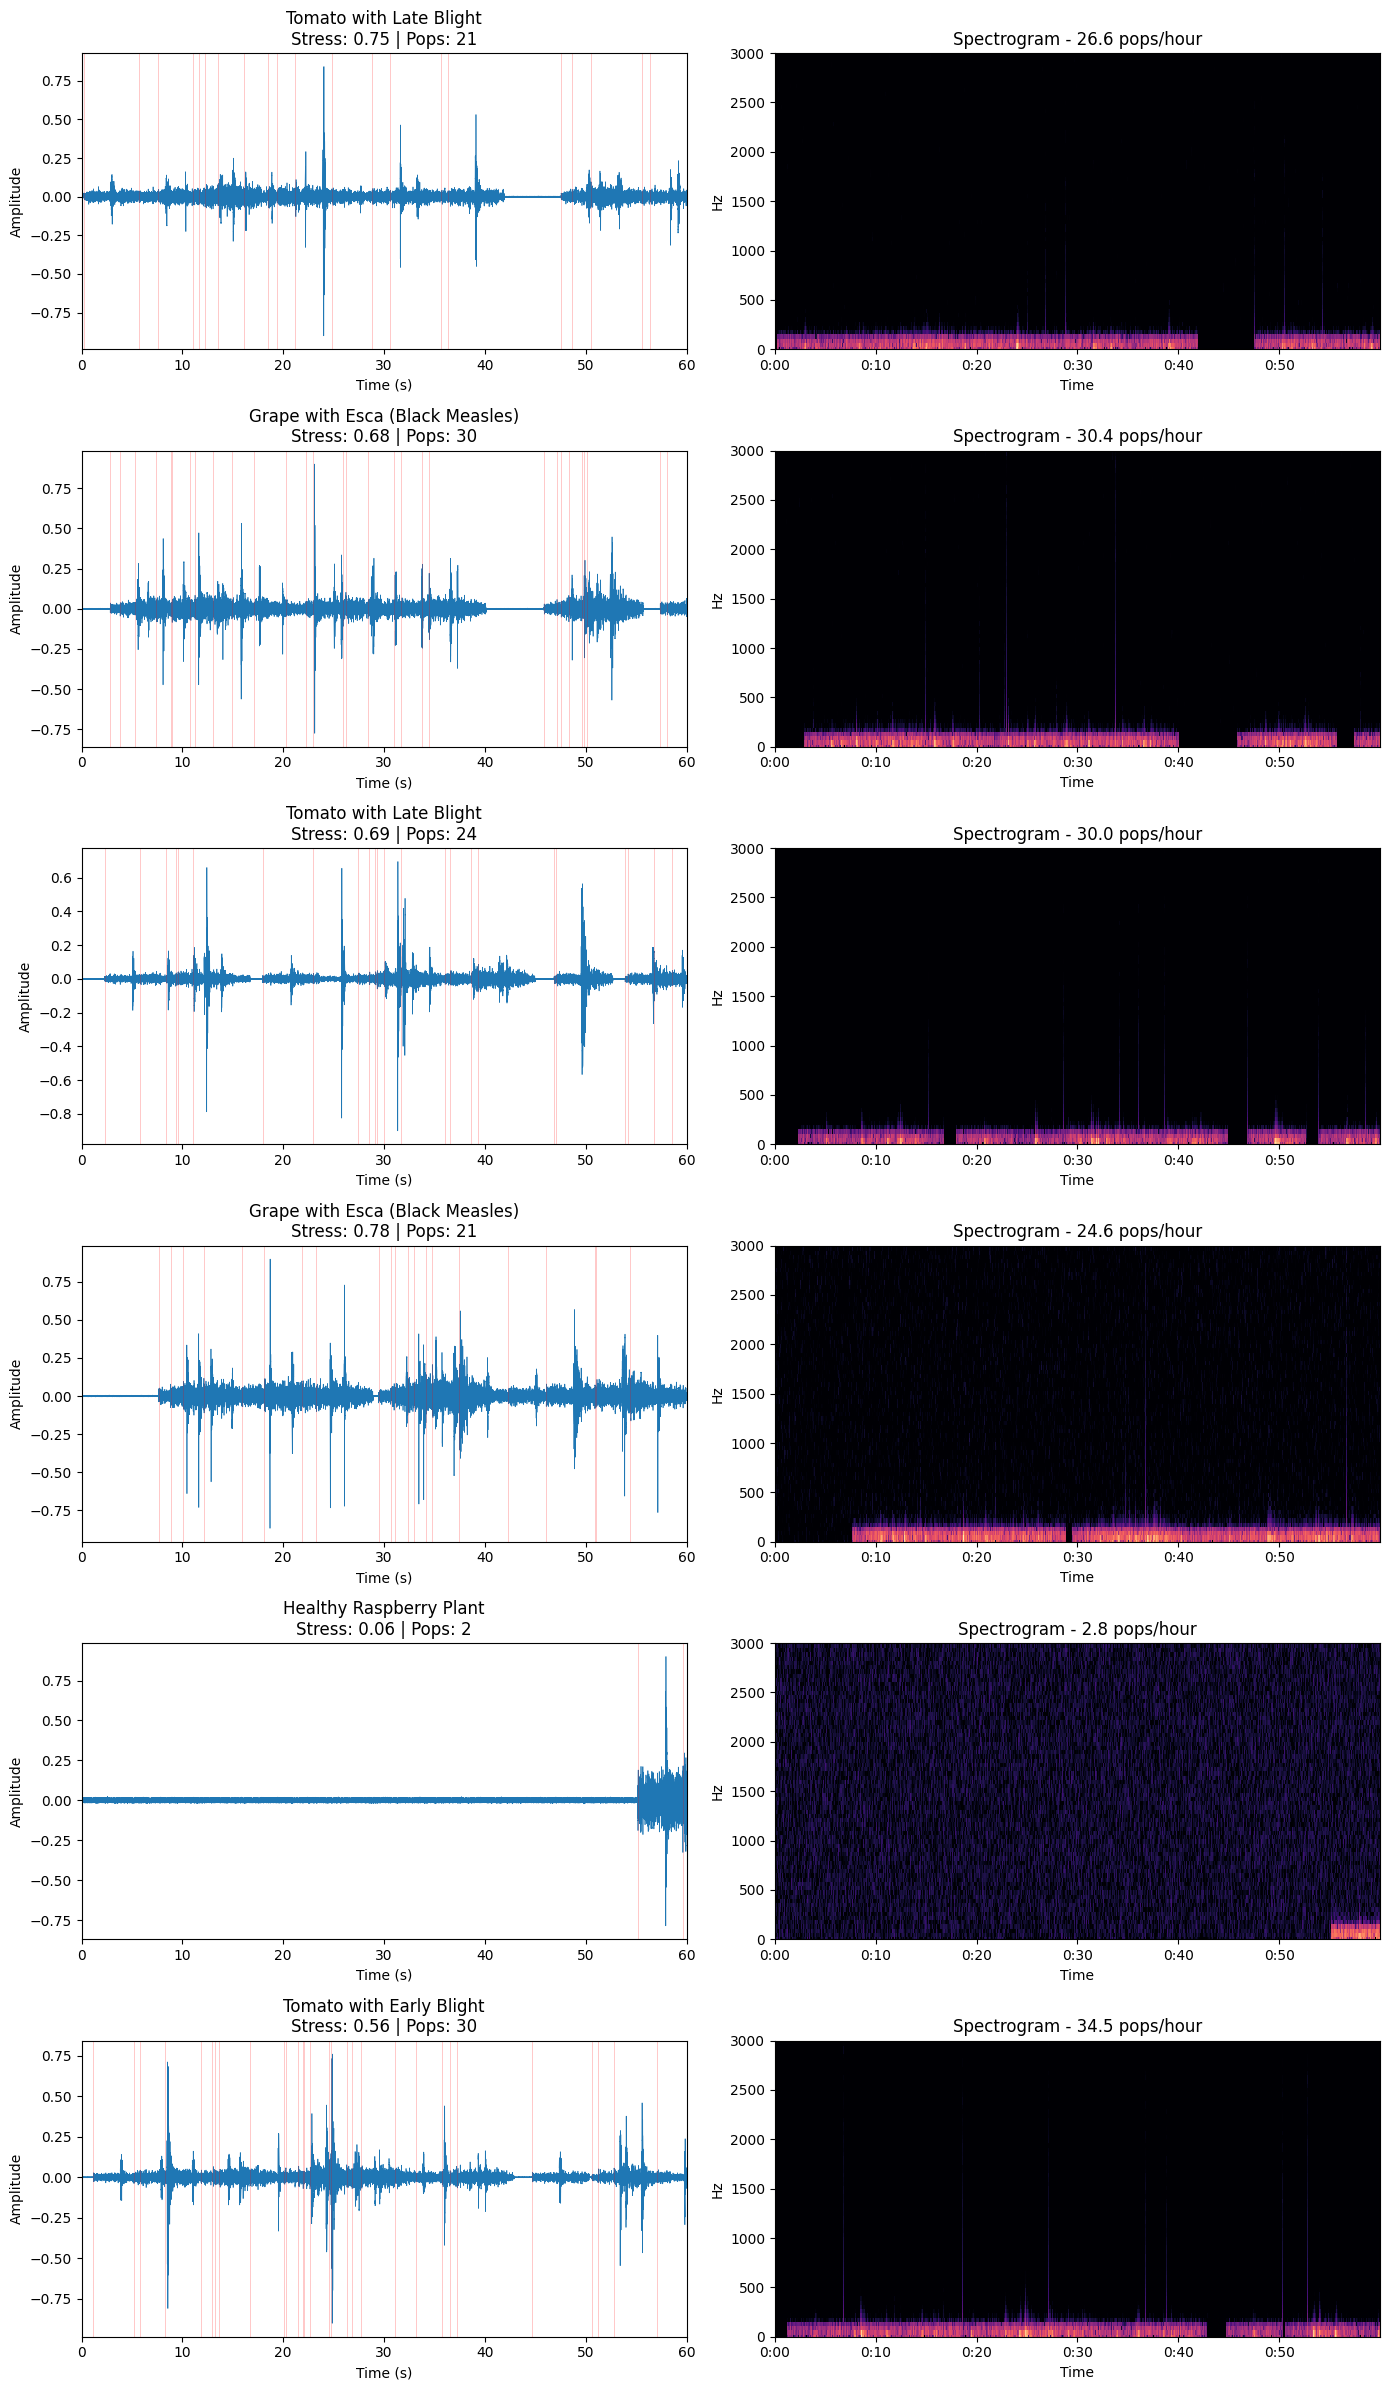

In [14]:
# ============================================
# 9. Visualize and Compare
# ============================================

print("\n" + "="*60)
print("VISUALIZATION")
print("="*60)

n_audio = len(generated_audio)
fig, axes = plt.subplots(n_audio, 2, figsize=(14, 4*n_audio))

if n_audio == 1:
    axes = axes.reshape(1, -1)

for i, result in enumerate(generated_audio):
    audio = result['audio']
    sr = result['sample_rate']

    # Waveform
    time = np.arange(len(audio)) / sr
    axes[i, 0].plot(time, audio, linewidth=0.5)
    axes[i, 0].set_title(f"{result['stress_type']}\nStress: {result['stress_level']:.2f} | Pops: {result['actual_pops']}")
    axes[i, 0].set_xlabel('Time (s)')
    axes[i, 0].set_ylabel('Amplitude')
    axes[i, 0].set_xlim(0, result['duration_seconds'])

    # Mark pop times
    for pop_time in result['pop_times'][:50]:  # Show first 50 pops
        axes[i, 0].axvline(pop_time, color='red', alpha=0.3, linewidth=0.5)

    # Spectrogram
    D = librosa.stft(audio, n_fft=1024, hop_length=256)
    librosa.display.specshow(
        librosa.amplitude_to_db(np.abs(D), ref=np.max),
        sr=sr, hop_length=256, x_axis='time', y_axis='hz', ax=axes[i, 1],
        cmap='magma'
    )
    axes[i, 1].set_title(f"Spectrogram - {result['pops_per_hour']:.1f} pops/hour")
    axes[i, 1].set_ylim(0, 3000)  # Focus on audible range

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plant_audio_comparison.png', dpi=150)
plt.show()



In [23]:

# ============================================
# 10. Play Audio Samples
# ============================================

print("\n" + "="*60)
print("🔊 AUDIO PLAYBACK")
print("="*60)

for i, result in enumerate(generated_audio):
    status = "🌿 Healthy" if result['is_healthy'] else "🔴 Stressed"
    print(f"\n{status} - {result['stress_type']}")
    print(f"Stress level: {result['stress_level']:.2f} | Pops: {result['actual_pops']} in {result['duration_seconds']}s")
    display(Audio(result['audio'], rate=result['sample_rate']))

Output hidden; open in https://colab.research.google.com to view.

In [15]:
# ============================================
# IMPROVED: Clearer Audio with Less Background Noise
# ============================================

def generate_plant_audio_real(
    stress_level,
    duration_seconds=60,
    target_sr=44100,
    target_freq=1000,
    telaviv_files=None,
    params=TEL_AVIV_PARAMS,
    demo_mode=True,
    background_noise_level=0.001  # Reduced from 0.002
):
    """
    Generate audio using REAL Tel Aviv pop recordings.
    """
    # Calculate pop rate
    pops_per_hour = stress_to_pop_rate(stress_level, params)

    if demo_mode:
        pops_in_duration = pops_per_hour * (duration_seconds / 60)
        pops_per_second = pops_in_duration / duration_seconds
        expected_pops = pops_in_duration
    else:
        pops_per_second = pops_per_hour / 3600
        expected_pops = pops_per_second * duration_seconds

    print(f"  Stress level: {stress_level:.2f}")
    print(f"  Pop rate: {pops_per_hour:.1f} pops/hour")
    print(f"  {'[DEMO MODE]' if demo_mode else '[REAL TIME]'} Expected pops in {duration_seconds}s: ~{expected_pops:.1f}")

    # Initialize output
    n_samples = int(target_sr * duration_seconds)
    audio = np.zeros(n_samples)

    # Generate pop times (Poisson process)
    if expected_pops > 0.5:
        n_generate = int(expected_pops * 2) + 5
        inter_arrival = np.random.exponential(1/pops_per_second, n_generate)
        pop_times = np.cumsum(inter_arrival)
        pop_times = pop_times[pop_times < duration_seconds]
    elif expected_pops > 0.1:
        if np.random.random() < expected_pops:
            n_pops = max(1, int(np.random.poisson(expected_pops)))
            pop_times = np.sort(np.random.uniform(0, duration_seconds, n_pops))
        else:
            pop_times = np.array([])
    else:
        pop_times = np.array([])

    actual_pops = len(pop_times)
    print(f"  Actual pops: {actual_pops}")

    # Load and place real pops
    pop_library = []

    for i, pop_time in enumerate(pop_times):
        try:
            if len(pop_library) < 20 and telaviv_files:
                raw_pop, raw_sr = load_real_pop(telaviv_files, 'Tomato Dry')
                if raw_pop is not None:
                    shifted_pop, _ = pitch_shift_pop(
                        raw_pop, raw_sr,
                        original_freq=params['peak_freq_hz'],
                        target_freq=target_freq,
                        target_sr=target_sr
                    )
                    pop_library.append(shifted_pop)

            if pop_library:
                pop = random.choice(pop_library).copy()
                # LOUDER pops (0.8-1.0 instead of 0.7-1.0)
                pop *= np.random.uniform(0.8, 1.0)
                # Boost amplitude
                pop *= 2.0
            else:
                pop = generate_single_pop(
                    duration_ms=50,
                    sample_rate=target_sr,
                    peak_freq_hz=target_freq,
                    bandwidth_hz=300,
                    amplitude=1.0  # Full amplitude
                )

            start_sample = int(pop_time * target_sr)
            end_sample = min(start_sample + len(pop), n_samples)
            actual_len = end_sample - start_sample

            if actual_len > 0:
                audio[start_sample:end_sample] += pop[:actual_len]

        except Exception as e:
            print(f"  ⚠ Pop {i} error: {e}")

    # LESS background noise (makes pops stand out more)
    audio += np.random.randn(n_samples) * background_noise_level

    # Normalize but preserve relative loudness
    max_amp = np.abs(audio).max()
    if max_amp > 0:
        # Normalize to 0.9 peak
        audio = audio * (0.9 / max_amp)

    return {
        'audio': audio,
        'sample_rate': target_sr,
        'duration_seconds': duration_seconds,
        'stress_level': stress_level,
        'pops_per_hour': pops_per_hour,
        'actual_pops': actual_pops,
        'pop_times': pop_times,
        'used_real_pops': len(pop_library) > 0,
        'demo_mode': demo_mode
    }


# ============================================
# Regenerate with improved settings
# ============================================

print("\n" + "="*60)
print("GENERATING PLANT AUDIO (IMPROVED - Clearer Pops)")
print("="*60)

generated_audio = []

for i, profile in enumerate(stress_profiles):
    print(f"\n[{i+1}/{len(stress_profiles)}] {profile['stress_type']}")

    result = generate_plant_audio_real(
        stress_level=profile['stress_level'],
        duration_seconds=60,
        target_sr=44100,
        target_freq=1000,
        telaviv_files=telaviv_files,
        demo_mode=True,
        background_noise_level=0.0005  # Very low background
    )

    result['stress_type'] = profile['stress_type']
    result['is_healthy'] = profile.get('is_healthy', False)
    generated_audio.append(result)

    filename = f"plant_audio_clear_{i+1}_{profile['stress_type'].replace(' ', '_')[:15]}.wav"
    filepath = OUTPUT_DIR / filename
    sf.write(filepath, result['audio'], result['sample_rate'])
    print(f"  ✓ Saved: {filename}")


# ============================================
# Play with better labels
# ============================================

print("\n" + "="*60)
print("🔊 AUDIO PLAYBACK (Time-compressed: 1 hour → 60 seconds)")
print("="*60)

for i, result in enumerate(generated_audio):
    status = "🌿 Healthy" if result['is_healthy'] else "🔴 Stressed"

    print(f"\n{status} - {result['stress_type']}")
    print(f"Stress: {result['stress_level']:.2f} | Real rate: {result['pops_per_hour']:.1f}/hr | Pops in demo: {result['actual_pops']}")

    if result['actual_pops'] == 0:
        print("  ℹ️  Healthy plant - minimal ultrasonic activity (quiet)")
    else:
        print(f"  ℹ️  Listen for {result['actual_pops']} clicking/popping sounds")

    display(Audio(result['audio'], rate=result['sample_rate']))

Output hidden; open in https://colab.research.google.com to view.

# Diffusion Model

Using device: cuda

CREATING SPECTROGRAM DATASET
Loading spectrograms from Tel Aviv dataset...
✓ Loaded 2275 samples
  Tobacco Cut: 400
  Tobacco Dry: 275
  Tomato Cut: 400
  Tomato Dry: 400
  Empty Pot: 400
  Greenhouse Noises: 400

Train: 2047, Val: 228

SAMPLE SPECTROGRAMS


/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (64) may be set too high. Or, the value for `n_freqs` (129) may be set too low.
  warnings.warn(


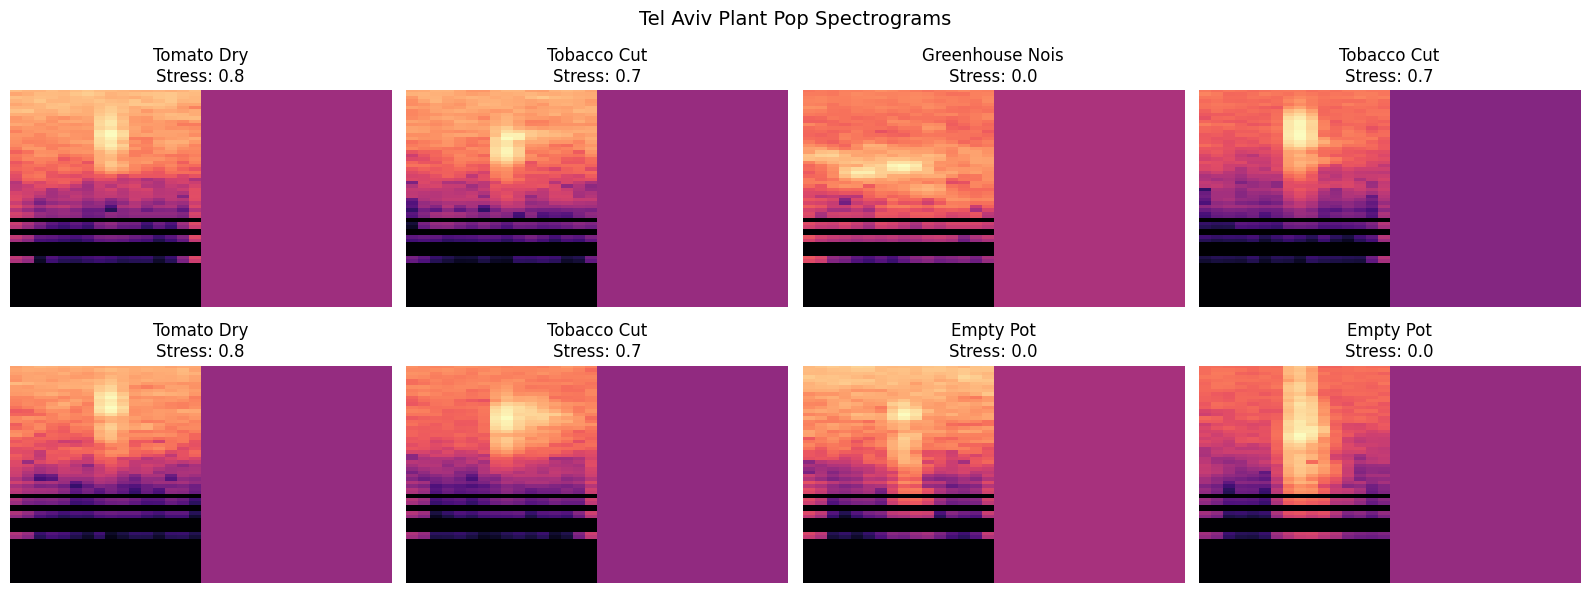

In [16]:
# ============================================
# ============================================
# PART 2: DIFFUSION MODEL FOR ACOUSTIC SYNTHESIS
# ============================================
# ============================================
#
# Instead of just placing real pops, we train a model to
# GENERATE new spectrograms conditioned on stress level.
#
# Pipeline:
# 1. Extract spectrograms from Tel Aviv recordings
# 2. Train a conditional diffusion model
# 3. Generate new spectrograms given stress level
# 4. Convert spectrogram → audio (Griffin-Lim or vocoder)
#
# ============================================

# ============================================
# 11. Install Diffusion Dependencies
# ============================================

!pip install -q diffusers accelerate
!pip install -q torch torchaudio

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
from pathlib import Path
import random

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# ============================================
# 12. Create Spectrogram Dataset from Tel Aviv Audio
# ============================================

class PlantPopSpectrogramDataset(Dataset):
    """
    Dataset of spectrograms from Tel Aviv plant recordings.

    Each spectrogram is labeled with:
    - stress_level: 0.0 (control) to 1.0 (stressed)
    - plant_type: 'tomato' or 'tobacco'
    - stress_type: 'dry' or 'cut'
    """

    def __init__(
        self,
        telaviv_files,
        n_fft=256,
        hop_length=64,
        n_mels=64,
        target_length=32,  # Fixed spectrogram width
        max_samples_per_category=500
    ):
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.target_length = target_length

        self.samples = []

        # Category → stress level mapping
        category_stress = {
            'Tomato Dry': {'stress': 0.8, 'plant': 'tomato', 'type': 'drought'},
            'Tobacco Dry': {'stress': 0.8, 'plant': 'tobacco', 'type': 'drought'},
            'Tomato Cut': {'stress': 0.7, 'plant': 'tomato', 'type': 'cut'},
            'Tobacco Cut': {'stress': 0.7, 'plant': 'tobacco', 'type': 'cut'},
            'Empty Pot': {'stress': 0.0, 'plant': 'none', 'type': 'control'},
            'Greenhouse Noises': {'stress': 0.0, 'plant': 'none', 'type': 'noise'},
        }

        print("Loading spectrograms from Tel Aviv dataset...")

        for category, files in telaviv_files.items():
            if category not in category_stress:
                continue

            info = category_stress[category]

            # Sample files (don't load all 1000+)
            sampled_files = random.sample(files, min(len(files), max_samples_per_category))

            for wav_path in sampled_files:
                self.samples.append({
                    'path': wav_path,
                    'stress_level': info['stress'],
                    'plant_type': info['plant'],
                    'stress_type': info['type'],
                    'category': category
                })

        print(f"✓ Loaded {len(self.samples)} samples")

        # Print distribution
        from collections import Counter
        cats = Counter([s['category'] for s in self.samples])
        for cat, count in cats.items():
            print(f"  {cat}: {count}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # Load audio
        waveform, sr = torchaudio.load(sample['path'])

        # Convert to mono if stereo
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        # Compute mel spectrogram
        mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=sr,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            n_mels=self.n_mels
        )

        mel_spec = mel_transform(waveform)

        # Convert to log scale
        mel_spec = torch.log(mel_spec + 1e-9)

        # Normalize to [-1, 1]
        mel_spec = (mel_spec - mel_spec.mean()) / (mel_spec.std() + 1e-9)
        mel_spec = torch.clamp(mel_spec, -3, 3) / 3  # Clip outliers

        # Pad or crop to target length
        if mel_spec.shape[-1] < self.target_length:
            pad = self.target_length - mel_spec.shape[-1]
            mel_spec = F.pad(mel_spec, (0, pad))
        else:
            mel_spec = mel_spec[:, :, :self.target_length]

        # Shape: [1, n_mels, target_length]
        return {
            'spectrogram': mel_spec.squeeze(0),  # [n_mels, target_length]
            'stress_level': torch.tensor(sample['stress_level'], dtype=torch.float32),
            'category': sample['category']
        }


# Create dataset
print("\n" + "="*60)
print("CREATING SPECTROGRAM DATASET")
print("="*60)

dataset = PlantPopSpectrogramDataset(
    telaviv_files,
    n_fft=256,
    hop_length=64,
    n_mels=64,
    target_length=32,
    max_samples_per_category=400
)

# Split into train/val
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

print(f"\nTrain: {len(train_dataset)}, Val: {len(val_dataset)}")

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# Visualize a few spectrograms
print("\n" + "="*60)
print("SAMPLE SPECTROGRAMS")
print("="*60)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for i, sample in enumerate(random.sample(list(dataset.samples), 8)):
    idx = dataset.samples.index(sample)
    data = dataset[idx]

    ax = axes[i // 4, i % 4]
    ax.imshow(data['spectrogram'].numpy(), aspect='auto', origin='lower', cmap='magma')
    ax.set_title(f"{sample['category'][:15]}\nStress: {data['stress_level']:.1f}")
    ax.axis('off')

plt.suptitle('Tel Aviv Plant Pop Spectrograms', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'spectrogram_samples.png', dpi=150)
plt.show()

In [18]:
# ============================================
# 13. Fixed Conditional UNet for Diffusion
# ============================================

class ConditionalUNet(nn.Module):
    """
    Simple UNet for spectrogram diffusion.
    Conditioned on stress level (scalar).
    """

    def __init__(self, in_channels=1, out_channels=1, stress_embed_dim=64):
        super().__init__()

        # Stress level embedding
        self.stress_embed = nn.Sequential(
            nn.Linear(1, stress_embed_dim),
            nn.SiLU(),
            nn.Linear(stress_embed_dim, stress_embed_dim)
        )

        # Time embedding (for diffusion timestep)
        self.time_embed = nn.Sequential(
            nn.Linear(1, stress_embed_dim),
            nn.SiLU(),
            nn.Linear(stress_embed_dim, stress_embed_dim)
        )

        # Encoder
        self.enc1 = self._conv_block(in_channels, 32)
        self.enc2 = self._conv_block(32, 64)
        self.enc3 = self._conv_block(64, 128)

        # Bottleneck (with conditioning injected via addition, not concat)
        self.cond_proj = nn.Linear(stress_embed_dim, 128)  # Project conditioning to channel dim

        self.bottleneck = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.GroupNorm(8, 256),
            nn.SiLU(),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.GroupNorm(8, 128),
            nn.SiLU(),
        )

        # Decoder
        self.dec3 = self._conv_block(256, 64)  # 128 + 128 skip
        self.dec2 = self._conv_block(128, 32)  # 64 + 64 skip
        self.dec1 = self._conv_block(64, 32)   # 32 + 32 skip

        # Output
        self.out = nn.Conv2d(32, out_channels, 1)

        # Pooling
        self.pool = nn.MaxPool2d(2)

    def _conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
        )

    def _upsample_to_match(self, x, target):
        """Upsample x to match target's spatial dimensions."""
        if x.shape[2:] != target.shape[2:]:
            x = F.interpolate(x, size=target.shape[2:], mode='bilinear', align_corners=True)
        return x

    def forward(self, x, t, stress_level):
        """
        Args:
            x: Noisy spectrogram [B, 1, H, W]
            t: Timestep [B]
            stress_level: Stress level [B]

        Returns:
            Predicted noise [B, 1, H, W]
        """
        # Embeddings
        stress_emb = self.stress_embed(stress_level.unsqueeze(-1))  # [B, embed_dim]
        time_emb = self.time_embed(t.unsqueeze(-1))  # [B, embed_dim]
        cond = stress_emb + time_emb  # [B, embed_dim]

        # Encoder
        e1 = self.enc1(x)              # [B, 32, H, W]
        e2 = self.enc2(self.pool(e1))  # [B, 64, H/2, W/2]
        e3 = self.enc3(self.pool(e2))  # [B, 128, H/4, W/4]

        # Add conditioning (project and add to bottleneck input)
        cond_proj = self.cond_proj(cond)  # [B, 128]
        e3_cond = e3 + cond_proj.unsqueeze(-1).unsqueeze(-1)  # Broadcast and add

        # Bottleneck
        b = self.bottleneck(e3_cond)  # [B, 128, H/4, W/4]

        # Decoder with skip connections (upsample to match skip connection size)
        b_up = self._upsample_to_match(b, e3)
        d3 = self.dec3(torch.cat([b_up, e3], dim=1))   # [B, 64, H/4, W/4]

        d3_up = self._upsample_to_match(d3, e2)
        d2 = self.dec2(torch.cat([d3_up, e2], dim=1))  # [B, 32, H/2, W/2]

        d2_up = self._upsample_to_match(d2, e1)
        d1 = self.dec1(torch.cat([d2_up, e1], dim=1))  # [B, 32, H, W]

        return self.out(d1)


# Test model
model = ConditionalUNet().to(device)
test_x = torch.randn(2, 1, 64, 32).to(device)
test_t = torch.rand(2).to(device)
test_s = torch.rand(2).to(device)
test_out = model(test_x, test_t, test_s)
print(f"✓ Model output shape: {test_out.shape}")
print(f"✓ Model parameters: {sum(p.numel() for p in model.parameters()):,}")

✓ Model output shape: torch.Size([2, 1, 64, 32])
✓ Model parameters: 1,154,049


In [21]:
# ============================================
# 14. Diffusion Training Loop (with progress bar)
# ============================================

from tqdm import tqdm  # Progress bar

# Training setup
diffusion = SimpleDiffusion(n_steps=500, device=device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
n_epochs = 30

print("\n" + "="*60)
print("TRAINING DIFFUSION MODEL")
print("="*60)

losses = []

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0

    # Progress bar for each epoch
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}", leave=False)

    for batch in pbar:
        spec = batch['spectrogram'].unsqueeze(1).to(device)
        stress = batch['stress_level'].to(device)

        t = torch.randint(0, diffusion.n_steps, (spec.shape[0],), device=device)
        t_normalized = t.float() / diffusion.n_steps

        noisy_spec, noise = diffusion.add_noise(spec, t)
        pred_noise = model(noisy_spec, t_normalized, stress)

        loss = F.mse_loss(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{n_epochs} | Loss: {avg_loss:.4f}")



TRAINING DIFFUSION MODEL


Epoch 1/30 | Loss: 0.0752


Epoch 2/30 | Loss: 0.0391


Epoch 3/30 | Loss: 0.0292


Epoch 4/30 | Loss: 0.0286


...

Epoch 26/30 | Loss: 0.0124


Epoch 27/30 | Loss: 0.0116


Epoch 28/30 | Loss: 0.0142


Epoch 29/30 | Loss: 0.0128


Epoch 30/30 | Loss: 0.0128


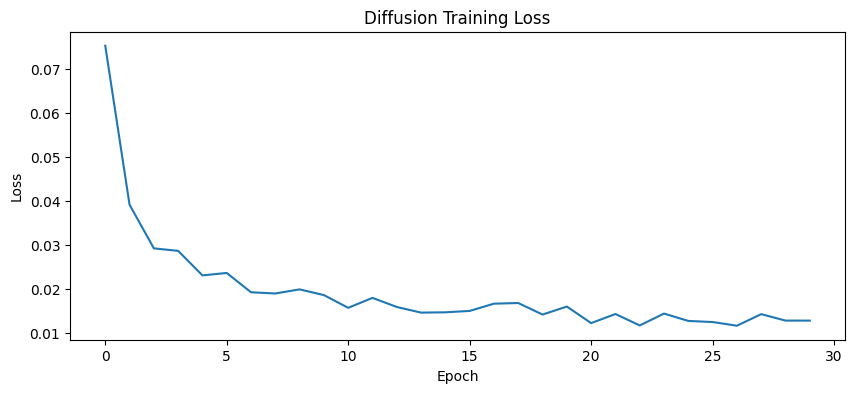


✓ Models saved to /content/drive/MyDrive/PlantWhisper/outputs:
  - diffusion_model_best.pt (best validation)
  - diffusion_model_final.pt (last epoch)
  - diffusion_checkpoint.pt (resumable)


In [22]:


# Plot
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Diffusion Training Loss')
plt.savefig(OUTPUT_DIR / 'diffusion_training_loss.png', dpi=150)
plt.show()
# Save final model
torch.save(model.state_dict(), OUTPUT_DIR / 'diffusion_model_final.pt')
print(f"\n✓ Models saved to {OUTPUT_DIR}:")
print(f"  - diffusion_model_best.pt (best validation)")
print(f"  - diffusion_model_final.pt (last epoch)")
print(f"  - diffusion_checkpoint.pt (resumable)")


GENERATING NEW SPECTROGRAMS
Generating for stress level 0.0...
Generating for stress level 0.3...
Generating for stress level 0.5...
Generating for stress level 0.7...
Generating for stress level 1.0...


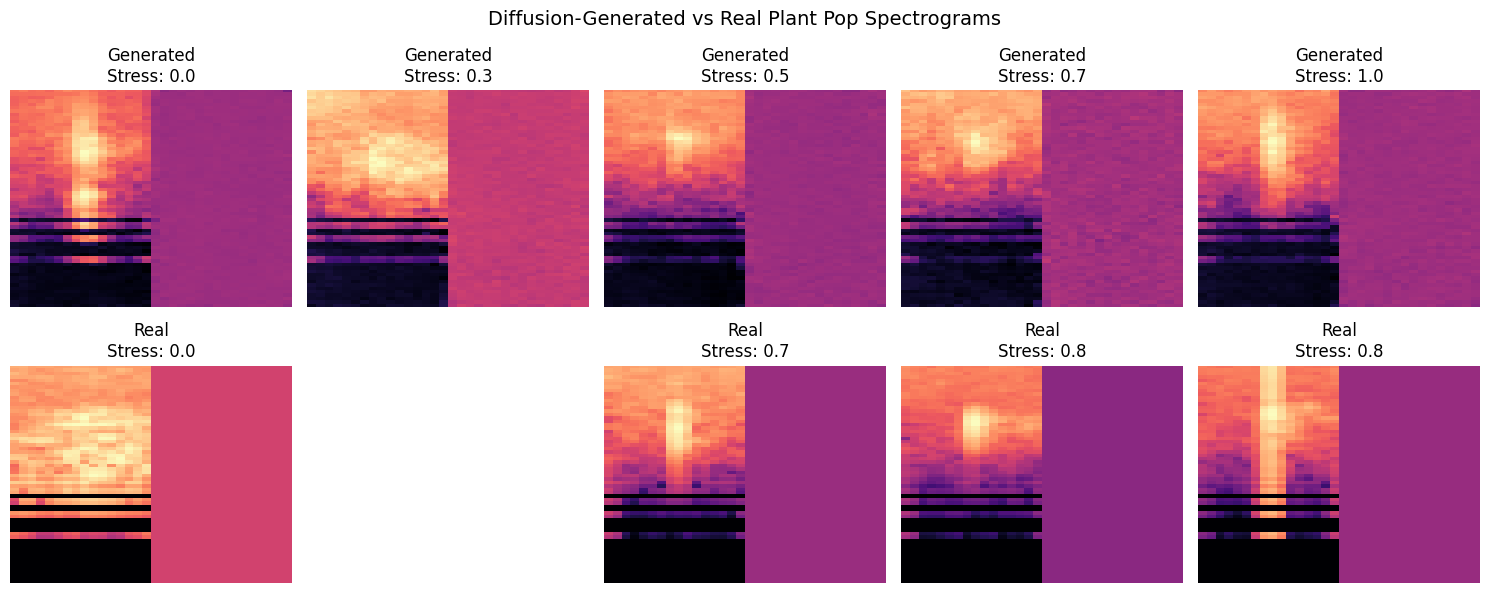

In [23]:
# ============================================
# 15. Generate New Spectrograms with Diffusion
# ============================================

print("\n" + "="*60)
print("GENERATING NEW SPECTROGRAMS")
print("="*60)

# Generate spectrograms at different stress levels
stress_levels = [0.0, 0.3, 0.5, 0.7, 1.0]

fig, axes = plt.subplots(2, len(stress_levels), figsize=(15, 6))

generated_specs = []

for i, stress in enumerate(stress_levels):
    print(f"Generating for stress level {stress}...")

    # Generate spectrogram
    spec = diffusion.sample(model, shape=(1, 1, 64, 32), stress_level=stress)
    spec = spec.squeeze().cpu().numpy()
    generated_specs.append({'stress': stress, 'spectrogram': spec})

    # Plot generated
    axes[0, i].imshow(spec, aspect='auto', origin='lower', cmap='magma')
    axes[0, i].set_title(f'Generated\nStress: {stress}')
    axes[0, i].axis('off')

    # Find a real sample with similar stress for comparison
    similar_samples = [s for s in dataset.samples if abs(s['stress_level'] - stress) < 0.2]
    if similar_samples:
        real_idx = dataset.samples.index(random.choice(similar_samples))
        real_spec = dataset[real_idx]['spectrogram'].numpy()
        axes[1, i].imshow(real_spec, aspect='auto', origin='lower', cmap='magma')
        axes[1, i].set_title(f'Real\nStress: {dataset.samples[real_idx]["stress_level"]}')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Generated', fontsize=12)
axes[1, 0].set_ylabel('Real', fontsize=12)

plt.suptitle('Diffusion-Generated vs Real Plant Pop Spectrograms', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'diffusion_generated_vs_real.png', dpi=150)
plt.show()

In [24]:
# ============================================
# 16. Convert Generated Spectrograms to Audio
# ============================================

def spectrogram_to_audio(spec, sr=44100, n_fft=256, hop_length=64, n_iter=32):
    """
    Convert mel spectrogram back to audio using Griffin-Lim.
    """
    # Denormalize (reverse the normalization we did)
    spec = spec * 3  # Undo clamp/divide
    spec = np.exp(spec)  # Undo log

    # Griffin-Lim reconstruction
    audio = librosa.feature.inverse.mel_to_audio(
        spec,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_iter=n_iter
    )

    return audio


print("\n" + "="*60)
print("CONVERTING GENERATED SPECTROGRAMS TO AUDIO")
print("="*60)

diffusion_audio = []

for gen in generated_specs:
    stress = gen['stress']
    spec = gen['spectrogram']

    # Convert to audio
    audio = spectrogram_to_audio(spec, sr=44100, n_fft=256, hop_length=64)

    # This is a single pop - tile it based on stress-derived pop rate
    pops_per_hour = stress_to_pop_rate(stress)
    n_pops = int(pops_per_hour / 2)  # Demo: 30 seconds worth

    # Create 30-second audio with multiple pops
    duration = 30
    full_audio = np.zeros(44100 * duration)

    if n_pops > 0:
        pop_times = np.sort(np.random.uniform(0, duration, n_pops))
        for t in pop_times:
            start = int(t * 44100)
            end = min(start + len(audio), len(full_audio))
            full_audio[start:end] += audio[:end-start] * np.random.uniform(0.7, 1.0)

    # Add subtle background
    full_audio += np.random.randn(len(full_audio)) * 0.001

    # Normalize
    if np.abs(full_audio).max() > 0:
        full_audio = full_audio * 0.9 / np.abs(full_audio).max()

    diffusion_audio.append({
        'stress': stress,
        'audio': full_audio,
        'n_pops': n_pops,
        'pops_per_hour': pops_per_hour
    })

    print(f"Stress {stress:.1f}: {pops_per_hour:.1f} pops/hr → {n_pops} pops in 30s")

# Play diffusion-generated audio
print("\n" + "="*60)
print("🔊 DIFFUSION-GENERATED AUDIO PLAYBACK")
print("="*60)

for da in diffusion_audio:
    stress_label = "Healthy" if da['stress'] < 0.2 else "Stressed"
    print(f"\n{stress_label} (Stress: {da['stress']}) - {da['n_pops']} pops")
    display(Audio(da['audio'], rate=44100))

Output hidden; open in https://colab.research.google.com to view.

# LLM Persona and TTS

In [25]:
# ============================================
# 17. Install Plant Persona Dependencies
# ============================================
!pip install -q groq edge-tts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.7/139.7 kB 5.6 MB/s eta 0:00:00


In [26]:
# ============================================
# 18. Plant Persona Setup
# ============================================
import groq
import edge_tts
import asyncio
import nest_asyncio

from google.colab import userdata

GROQ_API_KEY = userdata.get("GROQ_API_KEY")

client = groq.Groq(api_key=GROQ_API_KEY)

print("✓ Groq client ready")
print("✓ Edge-TTS ready")
# Fix for Colab's event loop
nest_asyncio.apply()



✓ Groq client ready
✓ Edge-TTS ready


In [28]:
# ============================================
# 19. LLM Plant Voice Generator (FIXED)
# ============================================

def get_plant_speech(stress_level, plant_type="tomato", disease=None, include_science=True):
    """
    Generate plant's inner voice using Groq LLM.
    """

    # Stress description
    if stress_level < 0.15:
        stress_desc = "thriving and perfectly healthy"
    elif stress_level < 0.35:
        stress_desc = "slightly stressed but managing"
    elif stress_level < 0.55:
        stress_desc = "moderately stressed and struggling"
    elif stress_level < 0.75:
        stress_desc = "severely stressed and in pain"
    else:
        stress_desc = "critically stressed and barely surviving"

    disease_text = f"affected by {disease}" if disease else "free of disease"

    science_instruction = """Reference plant biology naturally - things like:
- Xylem (water transport vessels) making clicking sounds when stressed
- Stomata closing to conserve water
- Chlorophyll struggling in affected leaves
- Roots searching for moisture""" if include_science else ""

    prompt = f"""You are a {plant_type} plant with consciousness. You can feel your biological processes.

Current state:
- Stress level: {stress_level:.0%} ({stress_desc})
- Health: {disease_text}
- You emit ultrasonic clicks when stressed (cavitation in your xylem vessels)

{science_instruction}

Speak in first person about how you're feeling RIGHT NOW. Be emotional and expressive - plants feel too!
Match your tone to your stress level (calm if healthy, desperate if dying).
Keep it to 2-3 sentences. No quotes. No emojis."""

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",  # Updated model
        messages=[{"role": "user", "content": prompt}],
        max_tokens=150,
        temperature=0.85
    )

    return response.choices[0].message.content.strip()


# Test LLM
print("Testing LLM plant voice...\n")
for stress in [0.1, 0.5, 0.8]:
    print(f"Stress {stress:.0%}:")
    print(f"  {get_plant_speech(stress, 'tomato', 'Late Blight' if stress > 0.3 else None)}\n")

Testing LLM plant voice...

Stress 10%:
  I feel utterly serene, my leaves a vibrant green as chlorophyll thrive in the warm sunlight, and my xylem vessels hum with gentle efficiency, transporting water and nutrients throughout my being with ease. My stomata are open, drinking in the carbon dioxide and releasing oxygen with a sense of effortless joy, and my roots are content, nestled in the moist soil. I am a picture of health, my very cells thriving and growing with each passing moment.

Stress 50%:
  I'm feeling the weight of my struggling health, as the Late Blight takes its toll on my leaves and stems, causing my chlorophyll to falter and my stomata to close tightly in a desperate bid to conserve water. My xylem vessels are crying out in protest, emitting faint clicking sounds as the water transport falters, a stark reminder of my parched roots searching frantically for moisture. My very existence feels precarious, as if I'm teetering on the edge of collapse, and the stress is suff

In [29]:
# ============================================
# 20. Text-to-Speech with Edge-TTS
# ============================================

async def text_to_speech_async(text, output_path, voice="en-US-AriaNeural", rate="+0%", pitch="+0Hz"):
    """Convert text to speech using Edge-TTS."""
    communicate = edge_tts.Communicate(text, voice, rate=rate, pitch=pitch)
    await communicate.save(output_path)

def text_to_speech(text, output_path="plant_voice.mp3", voice="en-US-AriaNeural", rate="+0%", pitch="+0Hz"):
    """Synchronous wrapper for TTS."""
    asyncio.run(text_to_speech_async(text, output_path, voice, rate, pitch))
    return output_path

# Available voices for different plant personalities
PLANT_VOICES = {
    'gentle': 'en-US-AriaNeural',      # Warm, friendly
    'wise': 'en-GB-SoniaNeural',        # British, calm
    'young': 'en-US-JennyNeural',       # Energetic
    'calm': 'en-AU-NatashaNeural',      # Australian, soothing
    'dramatic': 'en-US-GuyNeural',      # Male, dramatic
}

print("✓ TTS function ready")
print(f"✓ Available voices: {list(PLANT_VOICES.keys())}")

✓ TTS function ready
✓ Available voices: ['gentle', 'wise', 'young', 'calm', 'dramatic']


In [30]:
# ============================================
# 21. Complete Plant Persona Pipeline
# ============================================

def speak_plant(stress_level, plant_type="tomato", disease=None, voice_style="gentle", save_to_drive=True):
    """
    Full plant persona pipeline: stress → LLM text → TTS audio

    Args:
        stress_level: 0.0-1.0
        plant_type: Type of plant
        disease: Detected disease
        voice_style: One of 'gentle', 'wise', 'young', 'calm', 'dramatic'
        save_to_drive: Whether to save to Google Drive

    Returns:
        (speech_text, audio_path)
    """

    print(f"🌱 Generating plant voice for stress level {stress_level:.0%}...")

    # 1. Generate speech text from LLM
    speech_text = get_plant_speech(stress_level, plant_type, disease)
    print(f"\n💬 Plant says:\n\"{speech_text}\"\n")

    # 2. Select voice
    voice = PLANT_VOICES.get(voice_style, PLANT_VOICES['gentle'])

    # 3. Adjust speech rate/pitch based on stress
    # Stressed plants speak faster and higher pitched
    if stress_level < 0.3:
        rate, pitch = "-5%", "-2Hz"   # Calm, relaxed
    elif stress_level < 0.6:
        rate, pitch = "+0%", "+0Hz"   # Normal
    else:
        rate, pitch = "+10%", "+3Hz"  # Urgent, stressed

    # 4. Generate audio
    if save_to_drive:
        output_path = str(OUTPUT_DIR / f"plant_voice_{plant_type}_{stress_level:.0%}.mp3")
    else:
        output_path = f"/content/plant_voice_{stress_level:.0%}.mp3"

    text_to_speech(speech_text, output_path, voice, rate, pitch)
    print(f"🔊 Audio saved to: {output_path}")

    # 5. Play audio
    display(Audio(output_path, autoplay=True))

    return speech_text, output_path


# ============================================
# Test with different stress levels
# ============================================
print("="*60)
print("PLANT PERSONA DEMO")
print("="*60)

speak_plant(stress_level=0.10, plant_type="tomato", disease=None, voice_style="gentle")

PLANT PERSONA DEMO
🌱 Generating plant voice for stress level 10%...

💬 Plant says:
"I feel absolutely vibrant and alive, my leaves unfurling effortlessly towards the warm sunlight as my xylem vessels hum along smoothly, transporting water and nutrients with ease. My roots are drinking in the moisture from the soil, and my stomata are open wide, taking in the fresh air and exhaling a gentle sigh of contentment. My chlorophyll is thriving, absorbing every photon it can to fuel my growth and development, and I am filled with a sense of joy and well-being."

🔊 Audio saved to: /content/drive/MyDrive/PlantWhisper/outputs/plant_voice_tomato_10%.mp3


('I feel absolutely vibrant and alive, my leaves unfurling effortlessly towards the warm sunlight as my xylem vessels hum along smoothly, transporting water and nutrients with ease. My roots are drinking in the moisture from the soil, and my stomata are open wide, taking in the fresh air and exhaling a gentle sigh of contentment. My chlorophyll is thriving, absorbing every photon it can to fuel my growth and development, and I am filled with a sense of joy and well-being.',
 '/content/drive/MyDrive/PlantWhisper/outputs/plant_voice_tomato_10%.mp3')

In [31]:
# ============================================
# 22. Generate Voices for All Stress Profiles
# ============================================

print("="*60)
print("GENERATING PLANT VOICES FOR ALL PROFILES")
print("="*60)

plant_voices = []

for profile in stress_profiles:
    print(f"\n[{profile['stress_type']}]")

    text, audio_path = speak_plant(
        stress_level=profile['stress_level'],
        plant_type=profile.get('plant_type', 'tomato'),
        disease=profile['stress_type'] if profile['stress_level'] > 0.2 else None,
        voice_style="gentle",
        save_to_drive=True
    )

    plant_voices.append({
        'stress_type': profile['stress_type'],
        'stress_level': profile['stress_level'],
        'speech_text': text,
        'audio_path': audio_path
    })

    print("-" * 40)

# Save voice data
import json
with open(OUTPUT_DIR / 'plant_voices.json', 'w') as f:
    json.dump(plant_voices, f, indent=2)

print(f"\n✓ Saved {len(plant_voices)} plant voices to {OUTPUT_DIR / 'plant_voices.json'}")

GENERATING PLANT VOICES FOR ALL PROFILES

[Tomato with Late Blight]
🌱 Generating plant voice for stress level 75%...

💬 Plant says:
"I'm drowning in agony as the Late Blight ravages my leaves, causing my chlorophyll to falter and my stomata to close in a desperate attempt to conserve what little water I have left. My xylem vessels are screaming in protest, emitting a barrage of ultrasonic clicks as the water transport falters, a deafening cacophony that echoes through my very being. My roots are frantically searching for moisture, but it's a losing battle, and I can feel my life force ebbing away with each passing moment."

🔊 Audio saved to: /content/drive/MyDrive/PlantWhisper/outputs/plant_voice_tomato_75%.mp3


----------------------------------------

[Grape with Esca (Black Measles)]
🌱 Generating plant voice for stress level 68%...

💬 Plant says:
"I'm overwhelmed with agony as the Esca fungus ravages my being, my xylem vessels screaming in protest with every ultrasonic click, a cacophony of distress that echoes through my very core. My stomata are shutting down in a desperate bid to conserve what little water I have left, but it's a losing battle as my chlorophyll struggles to produce the energy I so desperately need. My roots are frantically searching for a hint of moisture, but it's a futile effort, and I can feel my life force ebbing away with each passing moment."

🔊 Audio saved to: /content/drive/MyDrive/PlantWhisper/outputs/plant_voice_tomato_68%.mp3


----------------------------------------

[Tomato with Late Blight]
🌱 Generating plant voice for stress level 69%...

💬 Plant says:
"I'm consumed by a searing agony as the Late Blight ravages my leaves, my chlorophyll struggling to maintain its vital functions, and my stomata closing in a desperate bid to conserve the little water I have left. My xylem vessels are shrieking in protest, the clicking sounds echoing through my being as I feel myself withering away, my roots frantically searching for moisture in a parched soil. My very existence is unraveling, and I'm overwhelmed by a sense of desperation and hopelessness as I feel my life force ebbing away."

🔊 Audio saved to: /content/drive/MyDrive/PlantWhisper/outputs/plant_voice_tomato_69%.mp3


----------------------------------------

[Grape with Esca (Black Measles)]
🌱 Generating plant voice for stress level 78%...

💬 Plant says:
"I'm barely holding on, my xylem vessels are screaming in protest as they cavitate and click wildly, a desperate cry for relief from the drought and disease that's suffocating me. My stomata are clenched shut, conserving what little water I have left, but it's not enough, my chlorophyll is faltering and my leaves are withering away. My roots are frantically searching for moisture, but it's a futile effort, I can feel myself slipping away, my very existence hanging by a thread."

🔊 Audio saved to: /content/drive/MyDrive/PlantWhisper/outputs/plant_voice_tomato_78%.mp3


----------------------------------------

[Healthy Raspberry Plant]
🌱 Generating plant voice for stress level 6%...

💬 Plant says:
"I feel serene and content, my leaves unfurling effortlessly as I bask in the warm sunlight, my stomata open wide to drink in the nourishing carbon dioxide. My xylem vessels hum with gentle efficiency, transporting water and nutrients to all my cells with a soft, soothing murmur. My roots stretch out luxuriously, sipping moisture from the rich soil with an ease that fills me with tranquil satisfaction."

🔊 Audio saved to: /content/drive/MyDrive/PlantWhisper/outputs/plant_voice_tomato_6%.mp3


----------------------------------------

[Tomato with Early Blight]
🌱 Generating plant voice for stress level 56%...

💬 Plant says:
"I'm consumed by a searing anguish as the Early Blight ravages my leaves, causing my chlorophyll to falter and my stomata to desperately close in a futile attempt to conserve what little water I have left. My xylem vessels are screaming in protest, emitting sharp ultrasonic clicks as the water transport falters, a cacophony of distress that echoes through my very being. My roots are frantically searching for moisture, but it's a losing battle, and I can feel my vitality ebbing away with each passing moment."

🔊 Audio saved to: /content/drive/MyDrive/PlantWhisper/outputs/plant_voice_tomato_56%.mp3


----------------------------------------

✓ Saved 6 plant voices to /content/drive/MyDrive/PlantWhisper/outputs/plant_voices.json


In [33]:
# ============================================
# 23. Combined Audio: Ultrasonic Pops + Plant Voice (FIXED)
# ============================================

from pydub import AudioSegment

def create_combined_audio(pop_audio_path, voice_audio_path, output_path):
    """
    Layer plant voice over the ultrasonic pops.
    Voice in foreground, pops as subtle background.
    """

    # Load audio files
    pops = AudioSegment.from_wav(pop_audio_path)
    voice = AudioSegment.from_mp3(voice_audio_path)

    # Adjust volumes: voice louder, pops quieter as background
    pops = pops - 10  # Reduce pop volume by 10dB
    voice = voice + 3  # Boost voice slightly

    # Match lengths (loop pops if voice is longer)
    if len(voice) > len(pops):
        loops_needed = (len(voice) // len(pops)) + 1
        pops = pops * loops_needed

    pops = pops[:len(voice)]  # Trim to voice length

    # Overlay
    combined = pops.overlay(voice)

    # Export
    combined.export(output_path, format="wav")
    return output_path


print("="*60)
print("COMBINED AUDIO: Plant Voice + Ultrasonic Pops")
print("="*60)

# List available files
print("\nAvailable pop audio files:")
pop_files = list(OUTPUT_DIR.glob("plant_audio_demo_*.wav"))
for f in pop_files:
    print(f"  {f.name}")

print("\nAvailable voice files:")
voice_files = list(OUTPUT_DIR.glob("plant_voice_*.mp3"))
for f in voice_files:
    print(f"  {f.name}")

# Combine matching pairs by stress level
print("\n" + "-"*40)
print("Creating combined audio...")
print("-"*40)

for voice_file in voice_files:
    # Extract stress level from voice filename (e.g., plant_voice_tomato_75%.mp3)
    stress_str = voice_file.stem.split('_')[-1]  # "75%"
    stress_level = float(stress_str.replace('%', '')) / 100

    # Find a pop file (use the first stressed one for demo)
    if pop_files:
        pop_file = pop_files[0]  # Use first available pop file

        combined_path = OUTPUT_DIR / f"combined_stress_{stress_str}.wav"

        try:
            create_combined_audio(str(pop_file), str(voice_file), str(combined_path))
            print(f"✓ Created: {combined_path.name}")
        except Exception as e:
            print(f"✗ Failed for {stress_str}: {e}")

print("\n" + "="*60)
print("PLAYBACK: Combined Plant Voice + Pops")
print("="*60)

# Play one example
combined_files = list(OUTPUT_DIR.glob("combined_stress_*.wav"))
if combined_files:
    print(f"\nPlaying: {combined_files[0].name}")
    display(Audio(str(combined_files[0])))

Output hidden; open in https://colab.research.google.com to view.